<a href="https://colab.research.google.com/github/janhavipatkar854/CSL701-CS42-Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Janhavi N Patkar Roll No : cs42


Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


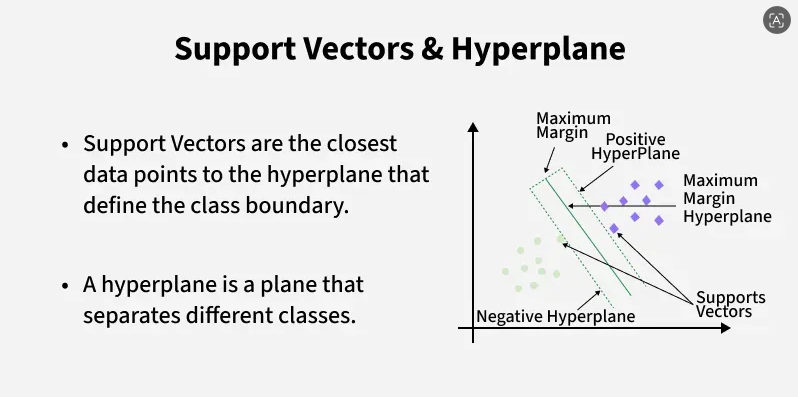
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:

# Task 1: Import Libraries and Load Dataset

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Add the target column
df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

# Display the first five rows
print("First five rows of the Iris dataset:")
display(df.head())

# Display the dataset shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
df.info()

# Display summary statistics
print("\nSummary statistics:")
display(df.describe())

First five rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset shape: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Summary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Task 2: Explore the Dataset

In [2]:

# Task 2: Explore the Dataset

# 1. Display the first five rows
print("First five rows of the dataset:")
display(df.head())

# 2. Display the last five rows
print("\nLast five rows of the dataset:")
display(df.tail())

# 3. Check the number of rows and columns
print("\nDataset shape:")
print(df.shape)

# 4. Display column names
print("\nColumn names:")
print(df.columns.tolist())

# 5. Check data types and non-null values
print("\nDataset information:")
df.info()

# 6. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# 7. Display statistical summary
print("\nStatistical summary:")
display(df.describe())

# 8. Count the number of samples in each species
print("\nSpecies distribution:")
print(df["species"].value_counts())

# 9. Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

First five rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last five rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Dataset shape:
(150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Number of duplicate rows:
1


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:

# Task 3: Select Features and Target

# Remove the Id column if it exists
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

# Select input features
X = df.drop(columns=["species"])

# Select target variable
y = df["species"]

# Display the selected features and target
print("Feature columns:")
print(X.columns.tolist())

print("\nFirst five rows of features (X):")
display(X.head())

print("\nFirst five values of target (y):")
display(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First five rows of features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First five values of target (y):


,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa



Shape of X: (150, 4)
Shape of y: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:

# Task 4: Split and Scale the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the datasets
print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Display a few scaled training samples
print("\nFirst five scaled training samples:")
display(pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head())

Training features shape: (120, 4)
Testing features shape: (30, 4)

Training target shape: (120,)
Testing target shape: (30,)

First five scaled training samples:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:

# Task 5: Implement Linear SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create the SVM model using a linear kernel
svm_model = SVC(kernel="linear", random_state=42)

# Train the model using the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = svm_model.predict(X_test_scaled)

# Display actual and predicted values
print("Actual values:")
print(y_test.to_numpy())

print("\nPredicted values:")
print(y_pred)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy: {:.2f}%".format(accuracy * 100))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Actual values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']

Predicted values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    acc

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Model Accuracy: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


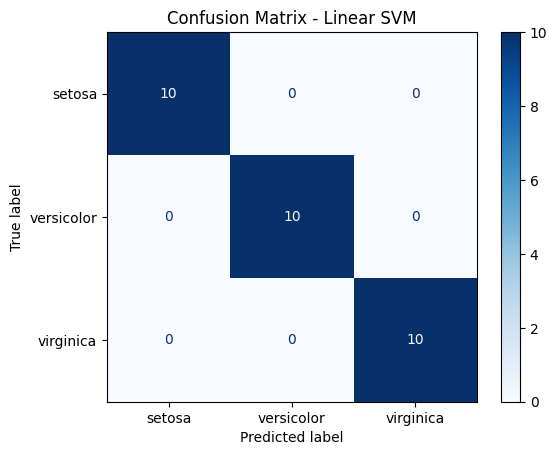


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:

# Task 6: Evaluate SVM

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("SVM Model Accuracy: {:.2f}%".format(accuracy * 100))

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# 3. Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

Selected Features:
   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2

Training data shape: (120, 2)
Testing data shape: (30, 2)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


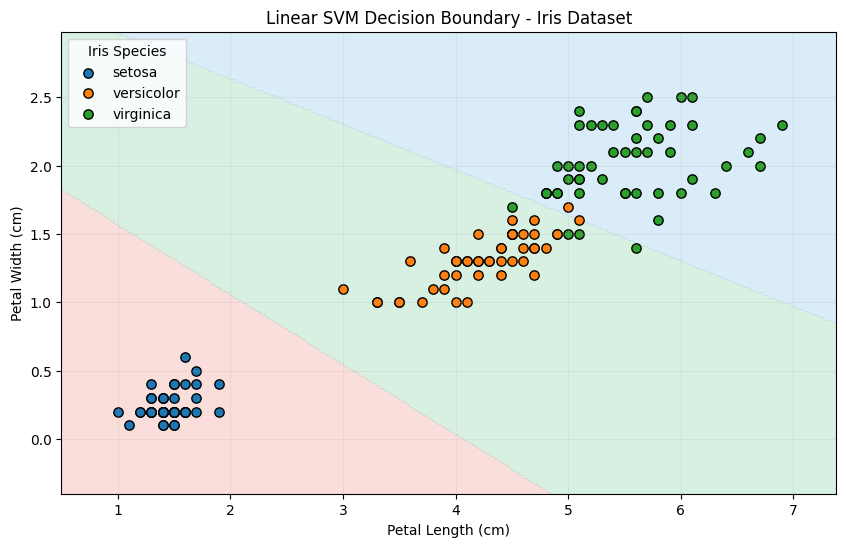


Linear SVM Accuracy using two features: 93.33%


In [7]:

# Task 7: Visualize SVM Decision Boundary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

# 1. Select Petal Length and Petal Width
X_2d = df[["petal length (cm)", "petal width (cm)"]]
y_2d = df["species"]

print("Selected Features:")
print(X_2d.head())

# 2. Split the data into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

print("\nTraining data shape:", X_train_2d.shape)
print("Testing data shape:", X_test_2d.shape)

# 3. Scale the selected features
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 4. Train SVM using a linear kernel
svm_2d = SVC(kernel="linear", random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# 5. Create a mesh grid in the original feature space
x_min, x_max = X_2d.iloc[:, 0].min() - 0.5, X_2d.iloc[:, 0].max() + 0.5
y_min, y_max = X_2d.iloc[:, 1].min() - 0.5, X_2d.iloc[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Scale grid points before prediction
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler_2d.transform(grid_points)

# Predict the class for each grid point
Z = svm_2d.predict(grid_points_scaled)

# Convert predicted species into numeric values for plotting
species_names = list(svm_2d.classes_)
Z_numeric = pd.Categorical(
    Z, categories=species_names
).codes.reshape(xx.shape)

# 6. Plot decision regions and data points
colors = ["#F5B7B1", "#A9DFBF", "#AED6F1"]
cmap = ListedColormap(colors)

plt.figure(figsize=(10, 6))

plt.contourf(
    xx, yy, Z_numeric,
    alpha=0.45,
    cmap=cmap,
    levels=np.arange(-0.5, len(species_names) + 0.5, 1)
)

# Plot the data points for each species
for i, species in enumerate(species_names):
    mask = y_2d == species
    plt.scatter(
        X_2d.loc[mask, "petal length (cm)"],
        X_2d.loc[mask, "petal width (cm)"],
        label=species,
        edgecolor="black",
        s=45
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Linear SVM Decision Boundary - Iris Dataset")
plt.legend(title="Iris Species")
plt.grid(alpha=0.2)
plt.show()

# Display model accuracy on the 2-D test set
y_pred_2d = svm_2d.predict(X_test_2d_scaled)

from sklearn.metrics import accuracy_score

accuracy_2d = accuracy_score(y_test_2d, y_pred_2d)
print("\nLinear SVM Accuracy using two features: {:.2f}%".format(
    accuracy_2d * 100
))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Accuracy: 93.33%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


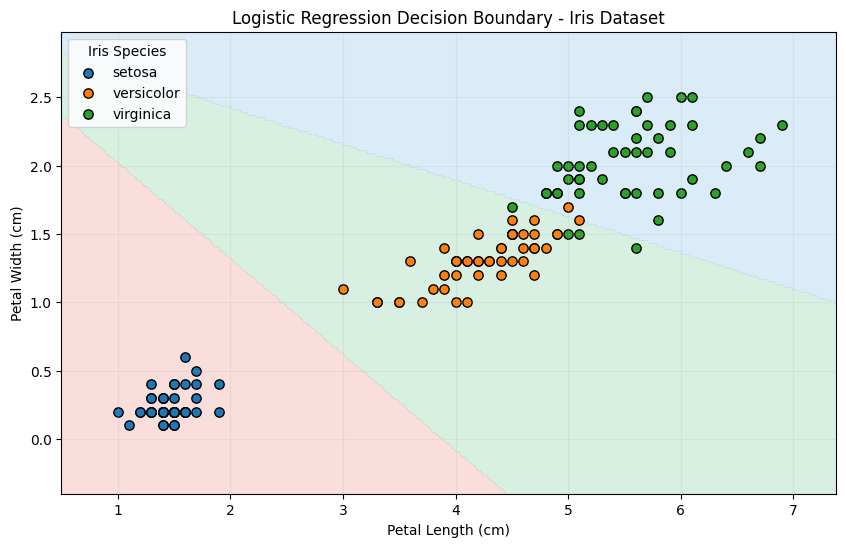

In [8]:

# Task 8: Normal Linear Classification Boundary
# Using Logistic Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# 1. Train Logistic Regression using the same scaled features
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_2d_scaled, y_train_2d)

# 2. Make predictions on the test dataset
y_pred_lr = lr_model.predict(X_test_2d_scaled)

# 3. Calculate accuracy
accuracy_lr = accuracy_score(y_test_2d, y_pred_lr)

print("Logistic Regression Accuracy: {:.2f}%".format(
    accuracy_lr * 100
))

# 4. Create a mesh grid in the original feature space
x_min, x_max = (
    X_2d["petal length (cm)"].min() - 0.5,
    X_2d["petal length (cm)"].max() + 0.5
)

y_min, y_max = (
    X_2d["petal width (cm)"].min() - 0.5,
    X_2d["petal width (cm)"].max() + 0.5
)

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 5. Scale grid points using the same scaler
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler_2d.transform(grid_points)

# Predict classes across the grid
Z_lr = lr_model.predict(grid_points_scaled)

# Convert class labels into numeric values for plotting
species_names = list(lr_model.classes_)
Z_lr_numeric = np.array([
    species_names.index(label) for label in Z_lr
]).reshape(xx.shape)

# 6. Plot Logistic Regression decision boundary
colors = ["#F5B7B1", "#A9DFBF", "#AED6F1"]
cmap = ListedColormap(colors)

plt.figure(figsize=(10, 6))

plt.contourf(
    xx, yy, Z_lr_numeric,
    alpha=0.45,
    cmap=cmap,
    levels=np.arange(-0.5, len(species_names) + 0.5, 1)
)

# Plot actual data points
for species in species_names:
    mask = y_2d == species

    plt.scatter(
        X_2d.loc[mask, "petal length (cm)"],
        X_2d.loc[mask, "petal width (cm)"],
        label=species,
        edgecolor="black",
        s=45
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Logistic Regression Decision Boundary - Iris Dataset")
plt.legend(title="Iris Species")
plt.grid(alpha=0.2)
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


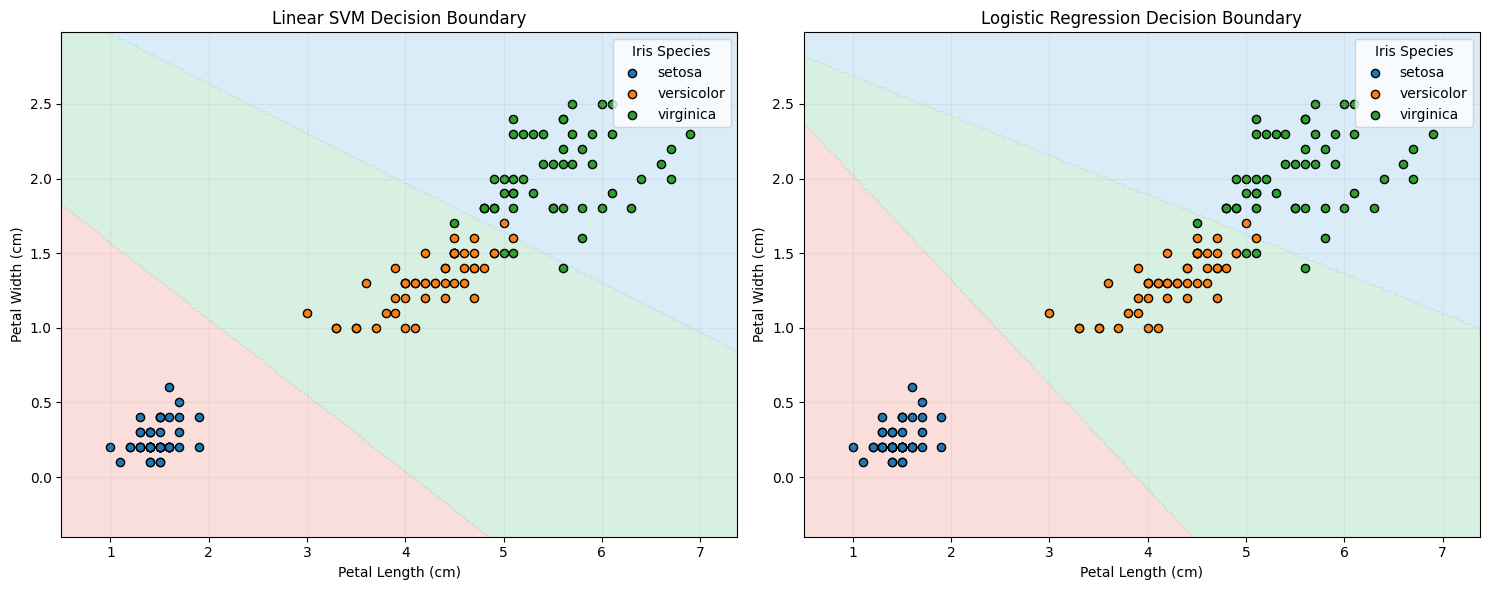

Linear SVM Accuracy: 93.33%
Logistic Regression Accuracy: 93.33%


In [9]:

# Task 9: Compare SVM and Logistic Regression Decision Boundaries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

# 1. Create a mesh grid using the two selected features
x_min = X_2d["petal length (cm)"].min() - 0.5
x_max = X_2d["petal length (cm)"].max() + 0.5
y_min = X_2d["petal width (cm)"].min() - 0.5
y_max = X_2d["petal width (cm)"].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 2. Scale the grid points using the existing scaler
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler_2d.transform(grid_points)

# 3. Predict classes using both trained models
Z_svm = svm_2d.predict(grid_points_scaled)
Z_lr = lr_model.predict(grid_points_scaled)

# Convert class labels into numeric values
species_names = list(svm_2d.classes_)

Z_svm = np.array([
    species_names.index(label) for label in Z_svm
]).reshape(xx.shape)

Z_lr = np.array([
    species_names.index(label) for label in Z_lr
]).reshape(xx.shape)

# 4. Define colors for the three species
cmap = ListedColormap(["#F5B7B1", "#A9DFBF", "#AED6F1"])

# 5. Plot both decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models = [
    (axes[0], Z_svm, "Linear SVM Decision Boundary"),
    (axes[1], Z_lr, "Logistic Regression Decision Boundary")
]

for ax, Z, title in models:
    ax.contourf(
        xx, yy, Z,
        alpha=0.45,
        cmap=cmap,
        levels=np.arange(-0.5, len(species_names) + 0.5, 1)
    )

    # Plot the same data points on both graphs
    for species in species_names:
        mask = y_2d == species

        ax.scatter(
            X_2d.loc[mask, "petal length (cm)"],
            X_2d.loc[mask, "petal width (cm)"],
            label=species,
            edgecolor="black",
            s=35
        )

    ax.set_xlabel("Petal Length (cm)")
    ax.set_ylabel("Petal Width (cm)")
    ax.set_title(title)
    ax.legend(title="Iris Species")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 6. Compare test accuracy
y_pred_svm = svm_2d.predict(X_test_2d_scaled)
y_pred_lr = lr_model.predict(X_test_2d_scaled)

svm_accuracy = accuracy_score(y_test_2d, y_pred_svm)
lr_accuracy = accuracy_score(y_test_2d, y_pred_lr)

print("Linear SVM Accuracy: {:.2f}%".format(svm_accuracy * 100))
print("Logistic Regression Accuracy: {:.2f}%".format(lr_accuracy * 100))

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

PERFORMANCE COMPARISON
----------------------------------------
Linear SVM Accuracy: 93.33%
Logistic Regression Accuracy: 93.33%

Linear SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


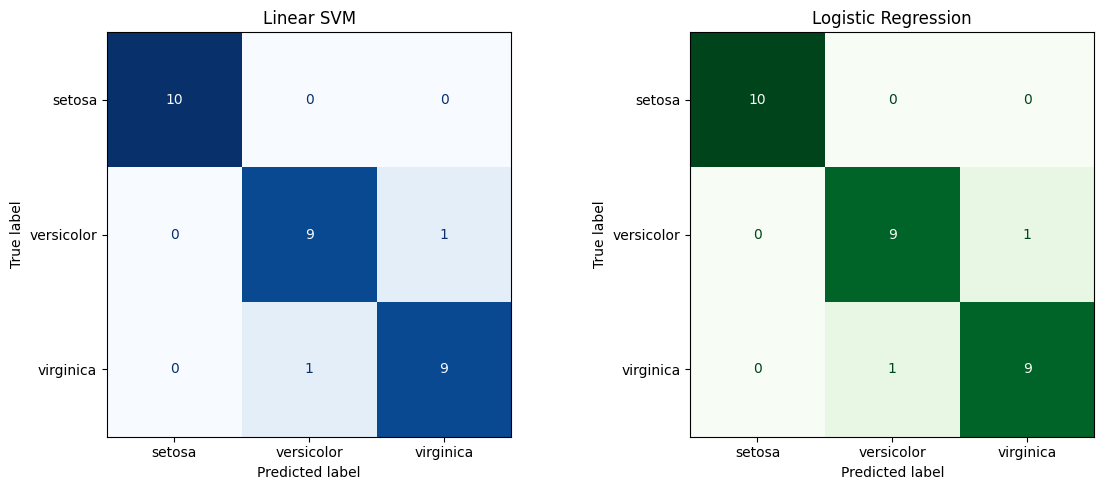


Linear SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Final Accuracy Comparison:


,Model,Accuracy (%)
0,Linear SVM,93.333333
1,Logistic Regression,93.333333


In [10]:

# Task 10: Compare Performance
# Linear SVM vs Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Make predictions using both models
y_pred_svm = svm_2d.predict(X_test_2d_scaled)
y_pred_lr = lr_model.predict(X_test_2d_scaled)

# 2. Calculate accuracy
svm_accuracy = accuracy_score(y_test_2d, y_pred_svm)
lr_accuracy = accuracy_score(y_test_2d, y_pred_lr)

print("PERFORMANCE COMPARISON")
print("-" * 40)
print("Linear SVM Accuracy: {:.2f}%".format(svm_accuracy * 100))
print("Logistic Regression Accuracy: {:.2f}%".format(lr_accuracy * 100))

# 3. Generate confusion matrices
cm_svm = confusion_matrix(
    y_test_2d, y_pred_svm,
    labels=svm_2d.classes_
)

cm_lr = confusion_matrix(
    y_test_2d, y_pred_lr,
    labels=lr_model.classes_
)

print("\nLinear SVM Confusion Matrix:")
print(cm_svm)

print("\nLogistic Regression Confusion Matrix:")
print(cm_lr)

# 4. Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_2d.classes_
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Linear SVM")

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

# 5. Generate classification reports
print("\nLinear SVM Classification Report:")
print(classification_report(
    y_test_2d, y_pred_svm,
    zero_division=0
))

print("\nLogistic Regression Classification Report:")
print(classification_report(
    y_test_2d, y_pred_lr,
    zero_division=0
))

# 6. Create a summary table
comparison = pd.DataFrame({
    "Model": ["Linear SVM", "Logistic Regression"],
    "Accuracy (%)": [
        svm_accuracy * 100,
        lr_accuracy * 100
    ]
})

print("\nFinal Accuracy Comparison:")
display(comparison)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.